# X-ray spectral fit: Gaussian line component, 31211+31996 epoch

Tests whether the ~2.9 keV residual feature seen in the 31211+31996 epoch's
continuum-only fits (`CLAUDE_xray_SOP.md`, "Advisor guidance 2026-09-02") is real
emission-line emission, by adding a Gaussian (`xsgaussian`) to 3 of the 4 continuum
models fit to this epoch: `powerlaw`, `bremss`, `bremss_powerlaw`. `apec` is excluded
(already a multi-line thermal plasma model) and no other epoch is touched -- this
figure and fit are specific to the best-constrained, final epoch
(~2550 days post-explosion, 506 counts).

**Method (per user direction 2026-09-03):** no X-ray data booklet species
identification, no attempt at the ~6.7 keV bump (not visible in the residuals at
this `group_counts(15)` binning). Two variants fit for each continuum model:
- **Free centroid:** `gau1.LineE`, `Sigma`, `norm` all thawed.
- **Fixed centroid:** `gau1.LineE` frozen at 2.9 keV, `Sigma`/`norm` thawed.

**Two robustness fixes applied during fitting** (see
`data/Chandra/spectral_fitting/fit_models_gauss.py` docstring for the full
empirical detail):
1. A naive single-start (or LineE-only multi-start) fit missed genuinely deeper
   minima reachable only from specific (LineE0, Sigma0) *combinations* -- fixed by
   multi-starting over the full (LineE0 x Sigma0) grid.
2. Without a width floor, the deepest minima converged to Gaussian widths
   (Sigma ~ 0.001-0.02 keV) far narrower than Chandra ACIS's actual energy
   resolution (FWHM ~ 130 eV -> Sigma ~ 0.055 keV via FWHM/2.355) -- i.e. the fit
   was using an unresolvably narrow spike to absorb a single noisy bin's excess
   counts, not modeling a real line. Fixed by setting `gau1.Sigma.min = 0.055` keV
   (the ACIS resolution floor) for every fit, so any surviving wstat improvement
   reflects a real, instrument-resolvable feature.

**Result:** `powerlaw` gains nothing physically meaningful (best free-centroid
minimum is broad, LineE~1.7 keV, not line-like; fixed-at-2.9 keV finds essentially
zero improvement). `bremss` and `bremss_powerlaw` both show a significant, narrow,
resolution-limited line at **~2.96 keV** (free centroid) / exactly 2.9 keV (fixed),
with the fitted Sigma landing right at the 0.055 keV instrumental floor in every
case -- consistent with a real but spectroscopically unresolved emission line, not
a fitting artifact. See `CLAUDE_xray_SOP.md` Step 4 for the full parameter table
and discussion.

Fit outputs: `data/Chandra/spectral_fitting/fits/fit_summary_gauss.csv` (free
centroid) and `fit_summary_gauss_fixed2p9.csv` (fixed at 2.9 keV), with per-model
`<model>_gauss/` and `<model>_gauss_fixed2p9/` subdirectories holding the folded
model curve and residuals at the `group_counts(15)` bin resolution. This notebook
plots the **free-centroid** result (the primary "agnostic" fit) as the main curve,
annotating the fixed-2.9-keV comparison alongside it. Run under the `18ivc_clean`
kernel -- fitting itself was done separately under `ciao-4.17` (Sherpa).

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import functions

functions.set_plot_style()

EPOCH_KEY = "31211_31996"
GROUPING_QA_DIR = "../data/Chandra/spectral_fitting/grouping_qa"
FITS_DIR = "../data/Chandra/spectral_fitting/fits"
BASELINE_SUMMARY_CSV = f"{FITS_DIR}/fit_summary.csv"
FREE_SUMMARY_CSV = f"{FITS_DIR}/fit_summary_gauss.csv"
FIXED_SUMMARY_CSV = f"{FITS_DIR}/fit_summary_gauss_fixed2p9.csv"

MODELS = ["powerlaw", "bremss", "bremss_powerlaw"]
MODEL_TITLES = {
    "powerlaw": "Power Law",
    "bremss": "Thermal Bremsstrahlung",
    "bremss_powerlaw": "Bremsstrahlung + Power Law",
}

# Single epoch (31211+31996) -- same viridis position as the other X-ray fit figures
# (CLAUDE_plotting.md canonical epoch list, x=0.100 for this epoch).
EPOCH_VIRIDIS_X = 0.100
SIGMA_FLOOR_KEV = 0.055

def darken_color(color, factor=0.6):
    rgb = mcolors.to_rgb(color)
    return tuple(factor * c for c in rgb)

cmap = mpl.colormaps["viridis"]
epoch_color = cmap(EPOCH_VIRIDIS_X)
gauss_color = darken_color(epoch_color, factor=0.55)
baseline_color = darken_color(epoch_color, factor=0.85)

baseline_summary = pd.read_csv(BASELINE_SUMMARY_CSV)
baseline_summary = baseline_summary[baseline_summary["epoch"] == EPOCH_KEY].set_index("model")

free_summary = pd.read_csv(FREE_SUMMARY_CSV).set_index("model")
fixed_summary = pd.read_csv(FIXED_SUMMARY_CSV).set_index("model")

def fmt_val_err(row, val_col, fmt="{:.3f}"):
    val = row[f"{val_col}_val"]
    pegged = row.get(f"{val_col}_pegged", False)
    near_floor = abs(val - SIGMA_FLOOR_KEV) < 1e-3
    val_s = fmt.format(val)
    if val_col == "gau1.Sigma" and (pegged or near_floor):
        return f"{val_s} (resolution-limited)"
    lo, hi = row.get(f"{val_col}_errlo"), row.get(f"{val_col}_errhi")
    if pd.notna(lo) and pd.notna(hi):
        return f"{val_s}$^{{+{fmt.format(hi)}}}_{{{fmt.format(lo)}}}$"
    return val_s

def panel_label(model_name):
    base_row = baseline_summary.loc[model_name]
    free_row = free_summary.loc[f"{model_name}_gauss"]
    fixed_row = fixed_summary.loc[f"{model_name}_gauss_fixed2p9"]

    base_w, base_dof = base_row["statval"], base_row["dof"]
    free_w, free_dof = free_row["statval"], free_row["dof"]
    fixed_w, fixed_dof = fixed_row["statval"], fixed_row["dof"]

    lines = [
        f"no gauss: $W$/dof = {base_w:.1f}/{base_dof:.0f}",
        f"+gauss (free): $W$/dof = {free_w:.1f}/{free_dof:.0f}  ($\\Delta W$={base_w-free_w:.1f})",
        f"  E = {fmt_val_err(free_row, 'gau1.LineE')} keV",
        f"  $\\sigma$ = {fmt_val_err(free_row, 'gau1.Sigma')} keV",
        f"+gauss (fixed 2.9 keV): $\\Delta W$={base_w-fixed_w:.1f}",
    ]
    return "\n".join(lines)


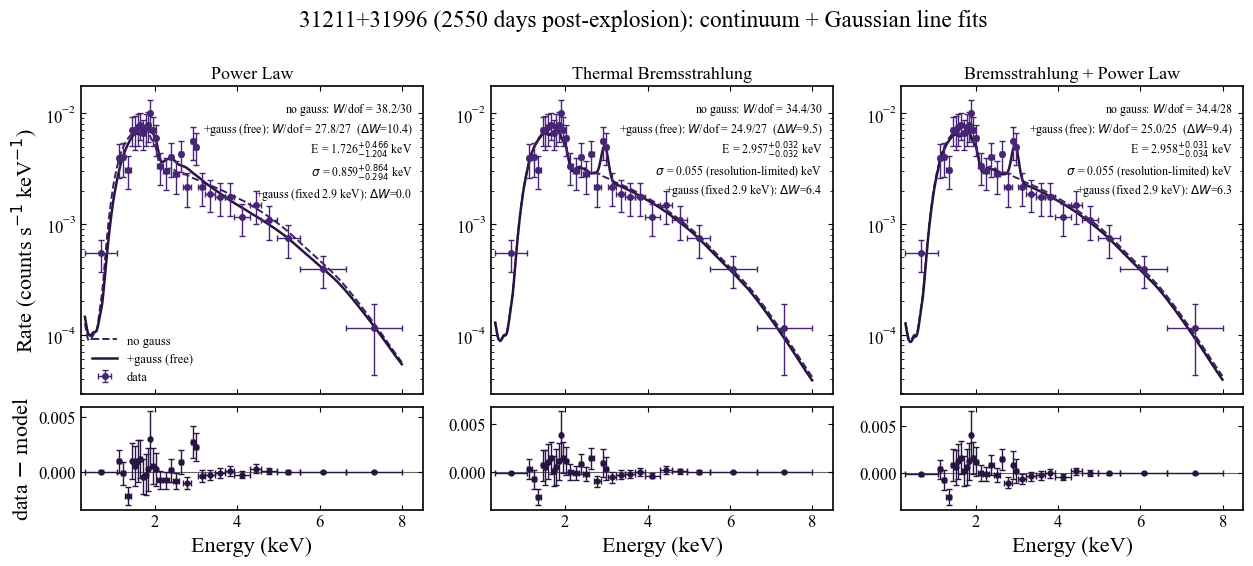

In [2]:
fig = plt.figure(figsize=(15, 5.5))
gs = fig.add_gridspec(2, 3, height_ratios=[3, 1], hspace=0.06)

spec_axes = [fig.add_subplot(gs[0, 0])]
spec_axes += [fig.add_subplot(gs[0, i], sharex=spec_axes[0], sharey=spec_axes[0]) for i in (1, 2)]
resid_axes = [fig.add_subplot(gs[1, i], sharex=spec_axes[i]) for i in range(3)]

df = pd.read_csv(f"{GROUPING_QA_DIR}/{EPOCH_KEY}_group15.csv")

for ax, rax, model_name in zip(spec_axes, resid_axes, MODELS):
    ax.errorbar(
        df["energy_kev"], df["rate"],
        xerr=df["energy_err_kev"], yerr=df["rate_err"],
        fmt="o", ms=4, capsize=2, lw=1.2, elinewidth=1,
        color=epoch_color, zorder=3, label="data",
    )

    base_mdf = pd.read_csv(f"{FITS_DIR}/{model_name}/{EPOCH_KEY}_model.csv")
    ax.plot(base_mdf["energy_kev"], base_mdf["rate"], "--", color=baseline_color, lw=1.4, zorder=2, label="no gauss")

    gauss_mdf = pd.read_csv(f"{FITS_DIR}/{model_name}_gauss/{EPOCH_KEY}_model.csv")
    ax.plot(gauss_mdf["energy_kev"], gauss_mdf["rate"], "-", color=gauss_color, lw=1.8, zorder=2, label="+gauss (free)")

    ax.set_title(MODEL_TITLES[model_name], fontsize=13)
    ax.set_yscale("log")
    ax.set_xlim(0.2, 8.5)
    ax.text(
        0.97, 0.95, panel_label(model_name), transform=ax.transAxes,
        ha="right", va="top", fontsize=8.5,
    )
    plt.setp(ax.get_xticklabels(), visible=False)

    rdf = pd.read_csv(f"{FITS_DIR}/{model_name}_gauss/{EPOCH_KEY}_resid.csv")
    rax.axhline(0, color="0.4", lw=0.8, zorder=1)
    rax.errorbar(
        rdf["energy_kev"], rdf["resid"],
        xerr=rdf["energy_err_kev"], yerr=rdf["resid_err"],
        fmt="o", ms=3.5, capsize=2, lw=1.0, elinewidth=1,
        color=gauss_color, zorder=3,
    )
    rax.set_xlim(0.2, 8.5)
    rax.set_xlabel("Energy (keV)")

spec_axes[0].set_ylabel(r"Rate (counts s$^{-1}$ keV$^{-1}$)")
spec_axes[0].legend(fontsize=9, frameon=False, loc="lower left")
resid_axes[0].set_ylabel("data $-$ model")

fig.suptitle("31211+31996 (2550 days post-explosion): continuum + Gaussian line fits", y=1.02)
fig.savefig("../figures/xray_spectra_31211_31996_gauss_fit.png", dpi=400, bbox_inches="tight")
fig.savefig("../figures/xray_spectra_31211_31996_gauss_fit.pdf", bbox_inches="tight")
plt.show()
